In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_practice_raw.csv")
df.head()


,order_id,order_date,customer_id,region,city,category,product,quantity,unit_price,discount,shipping_cost,payment_method,order_status
0,ORD001,2026-01-05,C001,Baku,Baku,Electronics,Mouse,2,25,0.00,3,Card,Delivered
1,ORD002,2026-01-07,C002,BAKU,Baku,Electronics,Keyboard,1,55,0.10,4,Cash,Delivered
2,ORD003,2026/01/09,C003,baku,Baku,Office,Notebook,5,6,0.00,2,Card,Delivered
3,ORD004,10-01-2026,C004,Ganja,Ganja,Electronics,Headphones,1,80,0.15,5,Card,Shipped
4,ORD005,2026-01-12,C005,Sumqayit,Sumqayit,Home,Lamp,2,35,0.05,4,Cash,Delivered


In [2]:
df.shape


(25, 13)

In [3]:
df.columns


Index(['order_id', 'order_date', 'customer_id', 'region', 'city', 'category',
       'product', 'quantity', 'unit_price', 'discount', 'shipping_cost',
       'payment_method', 'order_status'],
      dtype='str')

In [4]:
df.dtypes


order_id              str
order_date            str
customer_id           str
region                str
city                  str
category              str
product               str
quantity            int64
unit_price          int64
discount          float64
shipping_cost       int64
payment_method        str
order_status          str
dtype: object

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        25 non-null     str    
 1   order_date      25 non-null     str    
 2   customer_id     25 non-null     str    
 3   region          25 non-null     str    
 4   city            24 non-null     str    
 5   category        25 non-null     str    
 6   product         25 non-null     str    
 7   quantity        25 non-null     int64  
 8   unit_price      25 non-null     int64  
 9   discount        24 non-null     float64
 10  shipping_cost   25 non-null     int64  
 11  payment_method  24 non-null     str    
 12  order_status    25 non-null     str    
dtypes: float64(1), int64(3), str(9)
memory usage: 2.7 KB


In [6]:
df.describe()


,quantity,unit_price,discount,shipping_cost
count,25.000000,25.000000,24.000000,25.00
mean,3.840000,56.600000,0.045833,5.16
std,4.775633,101.178884,0.050898,3.30
min,1.000000,-260.000000,0.000000,2.00
25%,1.000000,6.000000,0.000000,3.00
50%,2.000000,35.000000,0.050000,4.00
75%,4.000000,80.000000,0.100000,8.00
max,20.000000,260.000000,0.150000,12.00


In [7]:
df.sample(5)


,order_id,order_date,customer_id,region,city,category,product,quantity,unit_price,discount,shipping_cost,payment_method,order_status
5,ORD006,2026-01-15,C006,Baku,Baku,Office,Pen,10,2,0.00,2,NaN,Delivered
20,ORD021,2026-02-25,C021,Baku,Baku,Electronics,Monitor,1,260,NaN,10,Card,Delivered
9,ORD010,2026-01-25,C010,Baku,Baku,Electronics,Monitor,1,260,0.10,10,Card,Delivered
10,ORD011,2026-02-02,C011,Ganja,Ganja,Home,Table,1,180,0.05,12,Cash,Delivered
2,ORD003,2026/01/09,C003,baku,Baku,Office,Notebook,5,6,0.00,2,Card,Delivered


### İlkin müşahidələr

- Dataset satış sifarişləri haqqında məlumat saxlayır.
- Tarix sütununda fərqli formatlar var.
- Missing value və duplicate qeydlər mövcuddur.
- `unit_price` sütununda qeyri-real mənfi dəyər var.


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
order_id          0
order_date        0
customer_id       0
region            0
city              1
category          0
product           0
quantity          0
unit_price        0
discount          1
shipping_cost     0
payment_method    1
order_status      0
dtype: int64

Duplicate rows:
1


In [9]:
print(df["region"].value_counts(dropna=False))


region
Baku        11
Ganja        6
Sumqayit     5
BAKU         1
baku         1
baku         1
Name: count, dtype: int64


In [10]:
print(df["order_date"].head(10))


0    2026-01-05
1    2026-01-07
2    2026/01/09
3    10-01-2026
4    2026-01-12
5    2026-01-15
6    2026-01-18
7    2026-01-20
8    2026-01-22
9    2026-01-25
Name: order_date, dtype: str


In [11]:
print(df["unit_price"].min())


-260


### Decision notes

**Problem:** Missing values var.  
**Nə etdim:** `city` və `payment_method` üçün `Unknown`, `discount` üçün `0` istifadə etdim.  
**Niyə:** Bu sütunlarda boş dəyərlərin analiz zamanı problem yaratmasının qarşısını almaq üçün.

**Problem:** Duplicate order var.  
**Nə etdim:** duplicate sətri sildim.  
**Niyə:** Eyni sifarişin iki dəfə sayılması KPI-ları şişirdə bilər.

**Problem:** Region yazılışları fərqlidir (`BAKU`, `baku`, `baku `).  
**Nə etdim:** `strip()` və `title()` istifadə etdim.  
**Niyə:** Eyni regionun ayrı kateqoriyalar kimi görünməsinin qarşısını almaq üçün.

**Problem:** Mənfi `unit_price` var.  
**Nə etdim:** həmin sətri çıxardım.  
**Niyə:** Məhsul qiymətinin mənfi olması real biznes baxımından mümkün deyil.

**Problem:** Tarixlər müxtəlif formatdadır.  
**Nə etdim:** `format="mixed"` və `dayfirst=True` istifadə etdim.  
**Niyə:** Müxtəlif tarix formatlarını düzgün tanımaq və düzgün tarixləri lazımsız yerə `NaT` etməmək üçün.


In [12]:
before_rows = len(df)
before_missing = df.isnull().sum().sum()
before_duplicates = df.duplicated().sum()

print("Before:")
print("Rows:", before_rows)
print("Missing:", before_missing)
print("Duplicates:", before_duplicates)


Before:
Rows: 25
Missing: 3
Duplicates: 1


In [13]:
# Tarixləri düzgün datetime tipinə çeviririk
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Text cleaning
df["region"] = df["region"].str.strip().str.title()
df["city"] = df["city"].fillna("Unknown").str.strip().str.title()

# Missing values
df["payment_method"] = df["payment_method"].fillna("Unknown")
df["discount"] = df["discount"].fillna(0)

# Duplicate silirik
df = df.drop_duplicates()

# Mənfi qiymətli sətri çıxarırıq
df = df[df["unit_price"] >= 0].copy()

# Yalnız həqiqətən tanınmayan tarixlər olarsa onları çıxarırıq
df = df.dropna(subset=["order_date"])

df.head()


,order_id,order_date,customer_id,region,city,category,product,quantity,unit_price,discount,shipping_cost,payment_method,order_status
0,ORD001,2026-05-01,C001,Baku,Baku,Electronics,Mouse,2,25,0.00,3,Card,Delivered
1,ORD002,2026-07-01,C002,Baku,Baku,Electronics,Keyboard,1,55,0.10,4,Cash,Delivered
2,ORD003,2026-09-01,C003,Baku,Baku,Office,Notebook,5,6,0.00,2,Card,Delivered
3,ORD004,2026-01-10,C004,Ganja,Ganja,Electronics,Headphones,1,80,0.15,5,Card,Shipped
4,ORD005,2026-12-01,C005,Sumqayit,Sumqayit,Home,Lamp,2,35,0.05,4,Cash,Delivered


In [14]:
after_rows = len(df)
after_missing = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

print("After:")
print("Rows:", after_rows)
print("Missing:", after_missing)
print("Duplicates:", after_duplicates)


After:
Rows: 23
Missing: 0
Duplicates: 0


In [15]:
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * df["discount"]
df["net_sales"] = df["gross_sales"] - df["discount_amount"]

df[["quantity","unit_price","discount","gross_sales","discount_amount","net_sales"]].head()


,quantity,unit_price,discount,gross_sales,discount_amount,net_sales
0,2,25,0.00,50,0.0,50.0
1,1,55,0.10,55,5.5,49.5
2,5,6,0.00,30,0.0,30.0
3,1,80,0.15,80,12.0,68.0
4,2,35,0.05,70,3.5,66.5


### Yeni sütunların məntiqi

- `gross_sales` = endirimdən əvvəl ümumi satış.
- `discount_amount` = verilən endirimin pul dəyəri.
- `net_sales` = endirimdən sonra satış məbləği.


In [16]:
total_orders = df["order_id"].nunique()
total_sales = df["net_sales"].sum()
average_order_value = df["net_sales"].mean()
total_units = df["quantity"].sum()
average_discount = df["discount"].mean()
total_shipping = df["shipping_cost"].sum()
delivered_orders = (df["order_status"] == "Delivered").sum()

print("Total orders:", total_orders)
print("Total sales:", round(total_sales, 2))
print("Average order value:", round(average_order_value, 2))
print("Total units sold:", total_units)
print("Average discount:", round(average_discount, 2))
print("Total shipping cost:", round(total_shipping, 2))
print("Delivered orders:", delivered_orders)


Total orders: 23
Total sales: 2127.9
Average order value: 92.52
Total units sold: 93
Average discount: 0.04
Total shipping cost: 115
Delivered orders: 20


### KPI şərhi

- **Total sales:** şirkətin əldə etdiyi ümumi net satış məbləği.
- **Average order value:** orta sifarişin dəyəri.
- **Total units:** satılan məhsul sayını göstərir.
- **Average discount:** müştərilərə verilən orta endirim səviyyəsidir.
- **Total shipping cost:** logistika xərclərini göstərir.
- **Delivered orders:** tamamlanmış sifarişlərin sayını göstərir.


In [17]:
# Baku regionunda və net sales 100-dən yuxarı sifarişlər
filter_1 = df[(df["region"] == "Baku") & (df["net_sales"] > 100)]
filter_1


,order_id,order_date,customer_id,region,city,category,product,quantity,unit_price,discount,shipping_cost,payment_method,order_status,gross_sales,discount_amount,net_sales
9,ORD010,2026-01-25,C010,Baku,Baku,Electronics,Monitor,1,260,0.1,10,Card,Delivered,260,26.0,234.0
11,ORD012,2026-04-02,C012,Baku,Unknown,Electronics,Keyboard,2,55,0.0,4,Card,Shipped,110,0.0,110.0
20,ORD021,2026-02-25,C021,Baku,Baku,Electronics,Monitor,1,260,0.0,10,Card,Delivered,260,0.0,260.0
23,ORD024,2026-04-03,C024,Baku,Baku,Electronics,Keyboard,2,55,0.0,4,Card,Delivered,110,0.0,110.0


In [18]:
# Electronics kateqoriyasında və 5%-dən çox endirim alan sifarişlər
filter_2 = df[(df["category"] == "Electronics") & (df["discount"] > 0.05)]
filter_2


,order_id,order_date,customer_id,region,city,category,product,quantity,unit_price,discount,shipping_cost,payment_method,order_status,gross_sales,discount_amount,net_sales
1,ORD002,2026-07-01,C002,Baku,Baku,Electronics,Keyboard,1,55,0.10,4,Cash,Delivered,55,5.5,49.5
3,ORD004,2026-01-10,C004,Ganja,Ganja,Electronics,Headphones,1,80,0.15,5,Card,Shipped,80,12.0,68.0
9,ORD010,2026-01-25,C010,Baku,Baku,Electronics,Monitor,1,260,0.10,10,Card,Delivered,260,26.0,234.0
14,ORD015,2026-11-02,C015,Ganja,Ganja,Electronics,Headphones,2,80,0.10,5,Card,Delivered,160,16.0,144.0


In [19]:
sales_by_region = df.groupby("region")["net_sales"].sum().sort_values(ascending=False)
sales_by_region


region
Baku        1043.8
Ganja        692.0
Sumqayit     392.1
Name: net_sales, dtype: float64

In [20]:
sales_by_category = df.groupby("category").agg(
    total_sales=("net_sales", "sum"),
    total_units=("quantity", "sum"),
    orders=("order_id", "nunique")
).sort_values("total_sales", ascending=False)

sales_by_category


,total_sales,total_units,orders
category,,,
Electronics,1148.0,17,10
Home,755.5,8,6
Office,224.4,68,7


### Insight
**Electronics** kateqoriyası **1,148.0 AZN** net sales ilə ən yüksək satışa malikdir. **Office** kateqoriyası isə **224.4 AZN** ilə ən aşağı göstəriciyə malikdir.


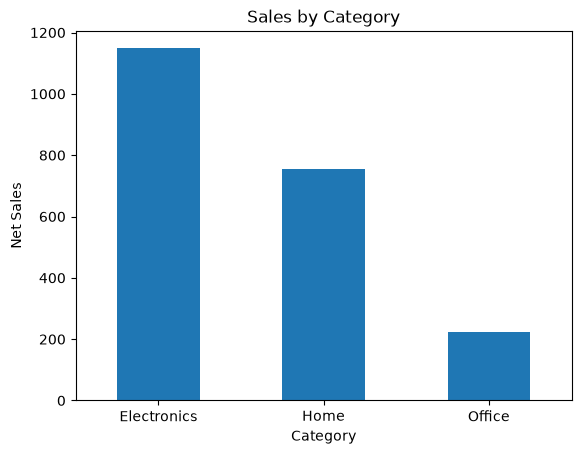

In [21]:
sales_by_category["total_sales"].plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net Sales")
plt.xticks(rotation=0)
plt.show()


### Insight
Sifarişlərin orta net sales dəyəri **92.52 AZN**-dir. Net sales dəyərləri **20 AZN-dən 260 AZN-ə** qədər dəyişir.


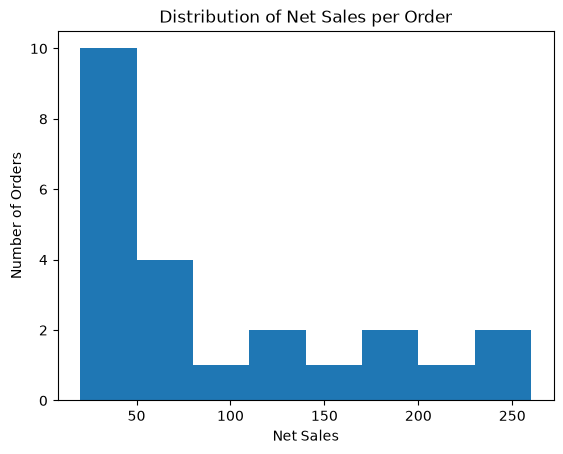

In [22]:
df["net_sales"].plot(kind="hist", bins=8)
plt.title("Distribution of Net Sales per Order")
plt.xlabel("Net Sales")
plt.ylabel("Number of Orders")
plt.show()


### Insight
Aylıq net sales yanvarda **746.6 AZN**, fevralda **1,235.3 AZN**, martda isə **146.0 AZN** olub. Fevralda pik, martda isə kəskin azalma müşahidə olunur.


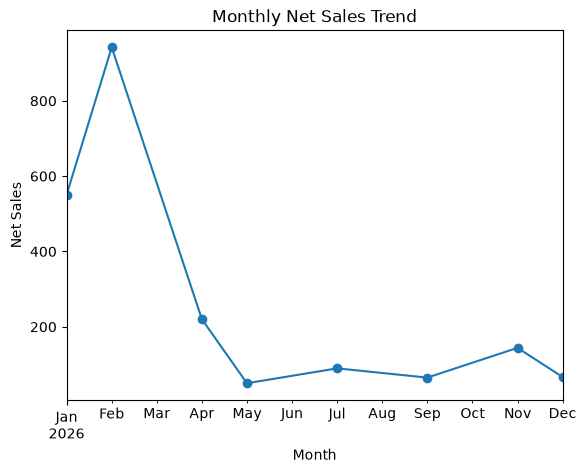

In [23]:
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["net_sales"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.show()


## 12. Data-backed insights

1. **Baku** regionu **1,043.8 AZN** net sales ilə ən yüksək nəticəyə malikdir; Ganja **692.0 AZN**, Sumqayit isə **392.1 AZN** göstərib.
2. **Electronics** kateqoriyası **1,148.0 AZN** net sales ilə birinci, **Home** **755.5 AZN**, **Office** isə **224.4 AZN** ilə sonuncudur.
3. Orta sifariş dəyəri **92.52 AZN** olub və sifarişlərin net sales dəyəri **20–260 AZN** aralığında dəyişib.
4. Aylıq satış fevralda **1,235.3 AZN** ilə pik həddə çatıb, martda isə **146.0 AZN**-ə düşüb; bu, mart ayında satış performansının zəiflədiyini göstərir.


## 13. Business recommendations

**Recommendation 1**  
**Problem:** Office kateqoriyasının satışları digər kateqoriyalardan aşağıdır.  
**Evidence:** Office net sales **224.4 AZN**, Electronics isə **1,148.0 AZN** təşkil edir.  
**Action:** Office kateqoriyasının məhsul çeşidini və kampaniyalarını nəzərdən keçirmək.  
**Monitor Metric:** Category net sales.

**Recommendation 2**  
**Problem:** Mart ayında satışlarda kəskin azalma var.  
**Evidence:** Net sales fevralda **1,235.3 AZN** olduğu halda martda **146.0 AZN** olub.  
**Action:** Mart ayındakı azalmanın səbəbini məhsul, region və sifariş statusu üzrə araşdırmaq.  
**Monitor Metric:** Monthly net sales.


# Final conclusion

Dataset yoxlanıldı və missing values, duplicate, inconsistent text, müxtəlif tarix formatları və numeric anomaly problemləri nəzərdən keçirildi. Tarixlər `format="mixed"` ilə düzgün çevrildiyi üçün düzgün tarixlərin lazımsız yerə itirilməsinin qarşısı alındı. Sonda 23 etibarlı sətr analiz üçün saxlanıldı.

Daha sonra 3 yeni satış göstəricisi yaradıldı, KPI-lar hesablandı, filter və groupby analizləri aparıldı və comparison, distribution və trend vizualları quruldu.

Əsas nəticələrə görə Baku regionu və Electronics kateqoriyası daha yüksək satış göstərir, mart ayında isə satışlarda ciddi azalma müşahidə olunur.
